# Netflix Top 10 Longevity Analysis

Which titles stay in the Netflix global Top 10 the longest, and what does that say about measuring success?

In [ ]:
# load datasets 
import pandas as pd

# load the three datasets
most_popular = pd.read_excel('most-popular-netflix.xlsx')
global_weekly = pd.read_excel('all-weeks-global-netflix.xlsx')
country_weekly = pd.read_excel('all-weeks-countries-netflix.xlsx')

#hide warnings 
import warnings
warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style, apply openpyxl's default"
)

In [20]:
# confirm datasets loaded by printing shapes
print("most_popular shape   →", most_popular.shape)
print("global_weekly shape  →", global_weekly.shape)
print("country_weekly shape →", country_weekly.shape)

most_popular shape   → (40, 7)
global_weekly shape  → (5840, 11)
country_weekly shape → (272260, 8)


In [22]:
# display column names and head for all datasets
print("most_popular columns:", most_popular.columns.tolist())
display(most_popular.head())

print("\nglobal_weekly columns:", global_weekly.columns.tolist())
display(global_weekly.head())

print("\ncountry_weekly columns:", country_weekly.columns.tolist())
display(country_weekly.head())

most_popular columns: ['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days']


,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000



global_weekly columns: ['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'runtime', 'weekly_views', 'cumulative_weeks_in_top_10', 'is_staggered_launch', 'episode_launch_details']


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN



country_weekly columns: ['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3


## Clean the Datasets

In [25]:
# check for missing or null values in each dataframe
print("== Null counts in most_popular ===")
print(most_popular.isnull().sum())

print("\n=== Null counts in global_weekly ===")
print(global_weekly.isnull().sum())

print("\n=== Null counts in country_weekly ===")
print(country_weekly.isnull().sum())

== Null counts in most_popular ===
category                       0
rank                           0
show_title                     0
season_title                  20
hours_viewed_first_91_days     0
runtime                        0
views_first_91_days            0
dtype: int64

=== Null counts in global_weekly ===
week                             0
category                         0
weekly_rank                      0
show_title                       0
season_title                  3026
weekly_hours_viewed              0
runtime                       4080
weekly_views                  4080
cumulative_weeks_in_top_10       0
is_staggered_launch              0
episode_launch_details        5768
dtype: int64

=== Null counts in country_weekly ===
country_name                       0
country_iso2                       0
week                               0
category                           0
weekly_rank                        0
show_title                         0
season_title            

I am ignoring the missing values in runtime and weekly_views because my analysis is focusing exclusively on cumulative weeks in the Top 10 (staying power), making those columns unnecessary to my story.

In [37]:
# display cureent datatypes for all columns
print("=== most_popular dtypes ===")
print(most_popular.dtypes)

print("\n=== global_weekly dtypes ===")
print(global_weekly.dtypes)

print("\n=== country_weekly dtypes ===")
print(country_weekly.dtypes)

=== most_popular dtypes ===
category                       object
rank                            int64
show_title                     object
season_title                   object
hours_viewed_first_91_days      int64
runtime                       float64
views_first_91_days             int64
dtype: object

=== global_weekly dtypes ===
week                           object
category                       object
weekly_rank                     int64
show_title                     object
season_title                   object
weekly_hours_viewed             int64
runtime                       float64
weekly_views                  float64
cumulative_weeks_in_top_10      int64
is_staggered_launch              bool
episode_launch_details         object
dtype: object

=== country_weekly dtypes ===
country_name                  object
country_iso2                  object
week                          object
category                      object
weekly_rank                    int64
show_title    

In [39]:
# convert week columns from object to datetime

# in global_weekly
global_weekly['week'] = pd.to_datetime(global_weekly['week'])

# in country_weekly
country_weekly['week'] = pd.to_datetime(country_weekly['week'])

# confirm the change
print("=== global_weekly dtypes after converting 'week' ===")
print(global_weekly.dtypes['week'])

print("\n=== country_weekly dtypes after converting 'week' ===")
print(country_weekly.dtypes['week'])


=== global_weekly dtypes after converting 'week' ===
datetime64[ns]

=== country_weekly dtypes after converting 'week' ===
datetime64[ns]


In [41]:
# inspect unique category labels
print("most_popular categories:", most_popular['category'].unique())
print("global_weekly categories:", global_weekly['category'].unique())
print("country_weekly categories:", country_weekly['category'].unique())


most_popular categories: ['Films (English)' 'Films (Non-English)' 'TV (English)' 'TV (Non-English)']
global_weekly categories: ['Films (English)' 'Films (Non-English)' 'TV (English)' 'TV (Non-English)']
country_weekly categories: ['Films' 'TV']


In [43]:
# standardize to “Film” or “TV”

# in most_popular
most_popular['category_simple'] = most_popular['category'].apply(
    lambda x: 'Film' if x.startswith('Film') else 'TV'
)

# in global_weekly
global_weekly['category_simple'] = global_weekly['category'].apply(
    lambda x: 'Film' if x.startswith('Film') else 'TV'
)

# in country_weekly
country_weekly['category_simple'] = country_weekly['category'].apply(
    lambda x: 'Film' if x == 'Films' else 'TV'
)

# confirm the new column
print("most_popular simplified counts:\n", most_popular['category_simple'].value_counts())
print("\nglobal_weekly simplified counts (sample):\n", global_weekly['category_simple'].value_counts().head())
print("\ncountry_weekly simplified counts (sample):\n", country_weekly['category_simple'].value_counts().head())


most_popular simplified counts:
 category_simple
Film    20
TV      20
Name: count, dtype: int64

global_weekly simplified counts (sample):
 category_simple
Film    2920
TV      2920
Name: count, dtype: int64

country_weekly simplified counts (sample):
 category_simple
Film    136130
TV      136130
Name: count, dtype: int64


In [46]:
# drop duplicates in each dataframe

print("Before dropping duplicates:")
print(" most_popular:", most_popular.shape)
print(" global_weekly:", global_weekly.shape)
print(" country_weekly:", country_weekly.shape)

most_popular   = most_popular.drop_duplicates()
global_weekly  = global_weekly.drop_duplicates()
country_weekly = country_weekly.drop_duplicates()

print("\nAfter dropping duplicates:")
print(" most_popular:", most_popular.shape)
print(" global_weekly:", global_weekly.shape)
print(" country_weekly:", country_weekly.shape)

Before dropping duplicates:
 most_popular: (40, 8)
 global_weekly: (5840, 12)
 country_weekly: (272260, 9)

After dropping duplicates:
 most_popular: (40, 8)
 global_weekly: (5840, 12)
 country_weekly: (272260, 9)


In [48]:
# create show_title_clean for joins

most_popular['show_title_clean']   = most_popular['show_title'].str.strip().str.lower()
global_weekly['show_title_clean']  = global_weekly['show_title'].str.strip().str.lower()
country_weekly['show_title_clean'] = country_weekly['show_title'].str.strip().str.lower()

# display a few samples to confirm
print("Sample 'most_popular' after cleaning titles:")
display(most_popular[['show_title', 'show_title_clean']].head())

print("\nSample 'global_weekly' after cleaning titles:")
display(global_weekly[['show_title', 'show_title_clean']].head())

print("\nSample 'country_weekly' after cleaning titles:")
display(country_weekly[['show_title', 'show_title_clean']].head())


Sample 'most_popular' after cleaning titles:


,show_title,show_title_clean
0,Red Notice,red notice
1,Don't Look Up,don't look up
2,The Adam Project,the adam project
3,Bird Box,bird box
4,Leave the World Behind,leave the world behind



Sample 'global_weekly' after cleaning titles:


,show_title,show_title_clean
0,What Jennifer Did,what jennifer did
1,Woody Woodpecker Goes to Camp,woody woodpecker goes to camp
2,Scoop,scoop
3,Glass,glass
4,Megan Leavey,megan leavey



Sample 'country_weekly' after cleaning titles:


,show_title,show_title_clean
0,The Tearsmith,the tearsmith
1,Stolen,stolen
2,"Love, Divided","love, divided"
3,Woody Woodpecker Goes to Camp,woody woodpecker goes to camp
4,Rest In Peace,rest in peace


## **Identify Top 5 Titles by Max Cumulative Weeks:**
I'm using the cleaned data to find the five titles with the highest cumulative weeks in the global Top 10, merge in their all-time hours from most_popular, and count the number of distinct countries from country_weekly. 

In [52]:
# compute maximum cumulative weeks for each title in global_weekly
max_weeks = (
    global_weekly
    .groupby('show_title_clean')['cumulative_weeks_in_top_10']
    .max()
    .reset_index(name='max_cumulative_weeks')
)

# merge to get original show_title from most_popular
max_weeks = max_weeks.merge(
    most_popular[['show_title_clean', 'show_title']],
    on='show_title_clean',
    how='left'
)

# sort and select top 5
top5_weeks = max_weeks.nlargest(5, 'max_cumulative_weeks').reset_index(drop=True)

print("Top 5 titles by maximum cumulative weeks:")
display(top5_weeks)

# merge in 'hours_viewed_first_91_days' from most_popular

top5_with_hours = top5_weeks.merge(
    most_popular[['show_title_clean', 'hours_viewed_first_91_days']],
    on='show_title_clean',
    how='left'
)

print("Top 5 titles with hours viewed in first 91 days:")
display(top5_with_hours)

# count distinct countries from country_weekly for each of the top 5

# filter country_weekly to only these top 5 shows
top5_titles = top5_weeks['show_title_clean'].tolist()
filtered_country = country_weekly[country_weekly['show_title_clean'].isin(top5_titles)]

# count unique countries per title
country_counts = (
    filtered_country
    .groupby('show_title_clean')['country_name']
    .nunique()
    .reset_index(name='n_countries')
)

# merge the country counts into top5_with_hours
top5_final = top5_with_hours.merge(country_counts, on='show_title_clean', how='left')

print("Top 5 titles with hours and number of countries reached:")
display(top5_final)


Top 5 titles by maximum cumulative weeks:


,show_title_clean,max_cumulative_weeks,show_title
0,"yo soy betty, la fea",30,NaN
1,café con aroma de mujer,28,NaN
2,manifest,25,NaN
3,all quiet on the western front,23,All Quiet on the Western Front
4,squid game,22,Squid Game


Top 5 titles with hours viewed in first 91 days:


,show_title_clean,max_cumulative_weeks,show_title,hours_viewed_first_91_days
0,"yo soy betty, la fea",30,NaN,NaN
1,café con aroma de mujer,28,NaN,NaN
2,manifest,25,NaN,NaN
3,all quiet on the western front,23,All Quiet on the Western Front,1.294000e+08
4,squid game,22,Squid Game,2.205200e+09


Top 5 titles with hours and number of countries reached:


,show_title_clean,max_cumulative_weeks,show_title,hours_viewed_first_91_days,n_countries
0,"yo soy betty, la fea",30,NaN,NaN,16
1,café con aroma de mujer,28,NaN,NaN,19
2,manifest,25,NaN,NaN,93
3,all quiet on the western front,23,All Quiet on the Western Front,1.294000e+08,91
4,squid game,22,Squid Game,2.205200e+09,94


## Charts

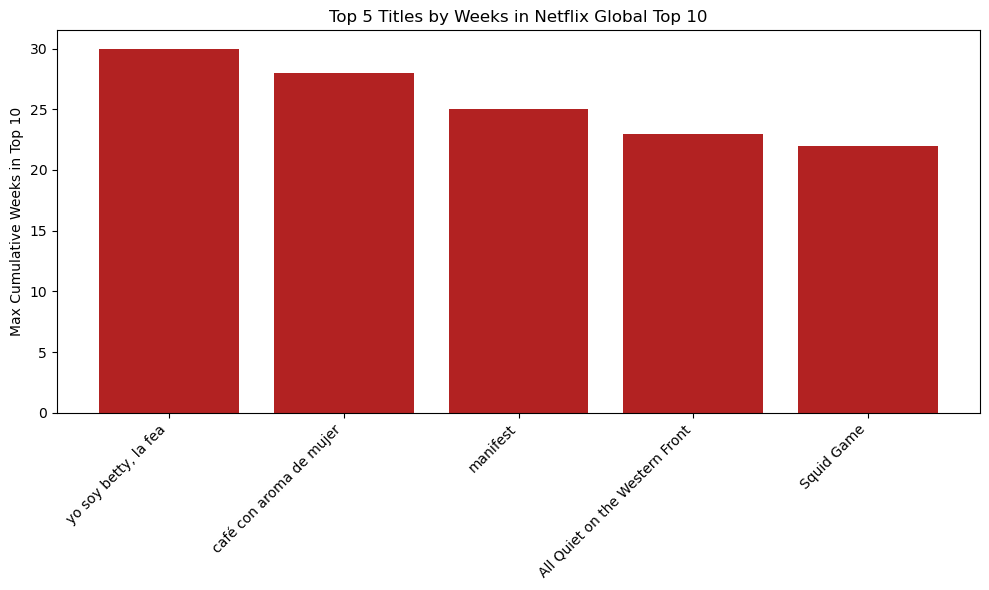

In [88]:
import matplotlib.pyplot as plt

# Chart 1: bar chart of Max Cumulative Weeks for Top 5 Titles
titles = top5_final['show_title'].fillna(top5_final['show_title_clean'])
weeks = top5_final['max_cumulative_weeks']

plt.figure(figsize=(10, 6))
plt.bar(titles, weeks, color='firebrick')  # Netflix‐style red
plt.xticks(rotation=45, ha='right')
plt.ylabel('Max Cumulative Weeks in Top 10')
plt.title('Top 5 Titles by Weeks in Netflix Global Top 10')
plt.tight_layout()
plt.savefig('chart_max_weeks.png', bbox_inches='tight')
plt.show()


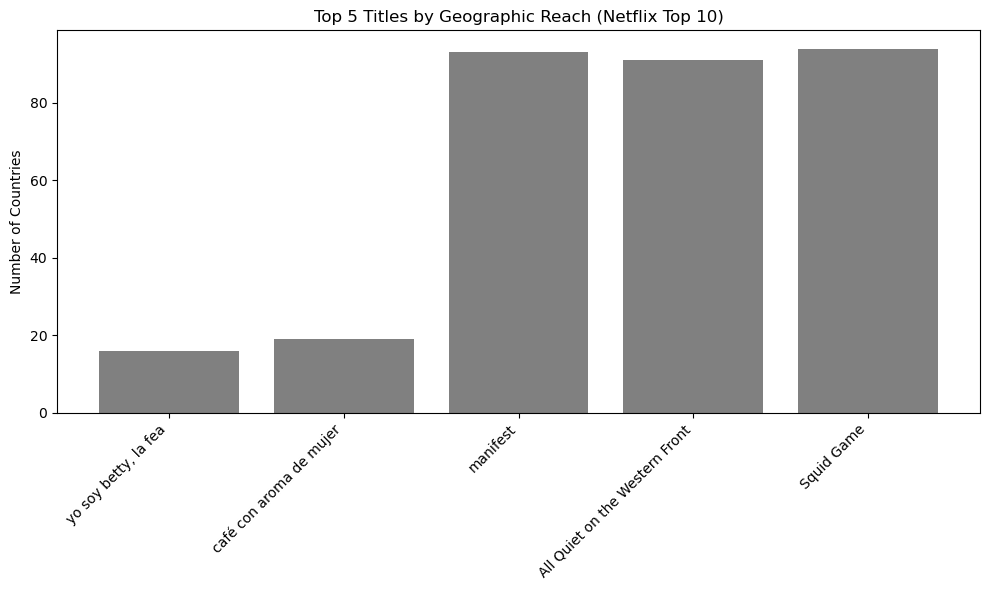

In [110]:
# Chart 2:bar chart of Number of Countries Reached for Top 5 Titles
titles = top5_final['show_title'].fillna(top5_final['show_title_clean'])
countries = top5_final['n_countries']

plt.figure(figsize=(10, 6))
plt.bar(titles, countries, color='grey') 
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Countries')
plt.title('Top 5 Titles by Geographic Reach (Netflix Top 10)')
plt.tight_layout()
plt.savefig('chart_countries_reached.png', bbox_inches='tight')
plt.show()


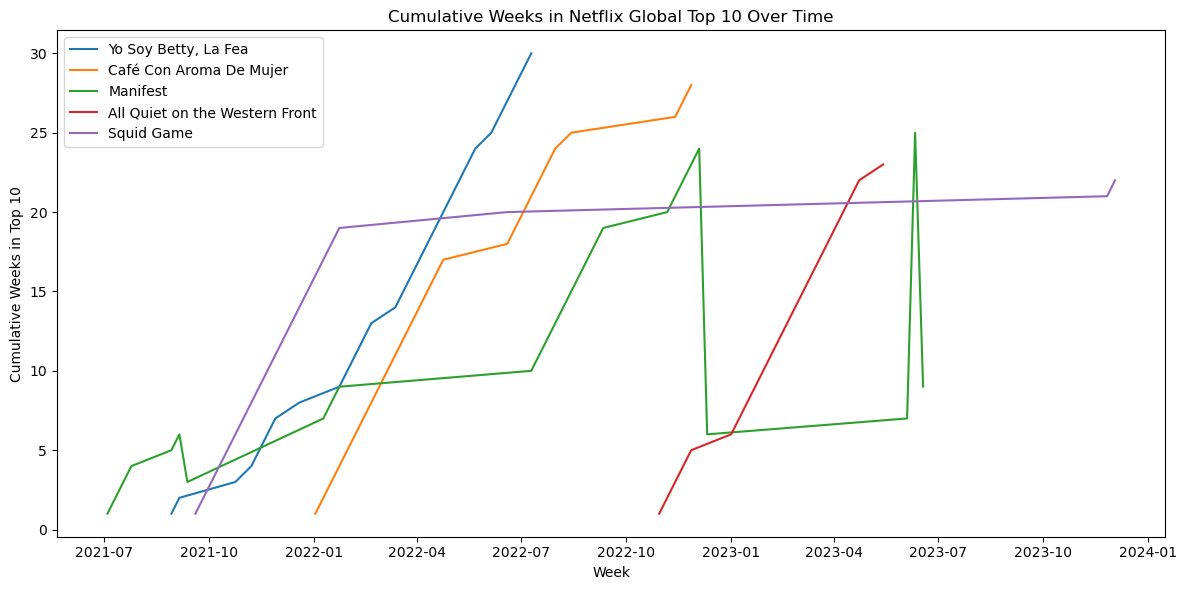

In [82]:
# Chart 3: smoothed line plot of cumulative weeks over time

# filter for just the Top 5
top5_titles = top5_final['show_title_clean'].tolist()
filtered_global = global_weekly[global_weekly['show_title_clean'].isin(top5_titles)].copy()

# drop duplicate weeks per title, keep highest cumulative week for each
filtered_global = (
    filtered_global.sort_values(['show_title_clean', 'week', 'cumulative_weeks_in_top_10'])
    .drop_duplicates(subset=['show_title_clean', 'week'], keep='last')
)

# plot
plt.figure(figsize=(12, 6))

for title in top5_titles:
    title_data = filtered_global[filtered_global['show_title_clean'] == title]
    title_data = title_data.sort_values('week')
    display_title = top5_final[top5_final['show_title_clean'] == title]['show_title'].values[0]
    display_title = display_title if pd.notnull(display_title) else title.title()
    
    plt.plot(title_data['week'], title_data['cumulative_weeks_in_top_10'], label=display_title)

plt.title('Cumulative Weeks in Netflix Global Top 10 Over Time')
plt.xlabel('Week')
plt.ylabel('Cumulative Weeks in Top 10')
plt.legend()
plt.tight_layout()
plt.savefig('chart_cumulative_weeks_over_time_cleaned.png', bbox_inches='tight')
plt.show()


In [139]:
# Chart 4: fix missing titles by filling in with title-cased version of show_title_clean
top5_final['Title'] = top5_final['show_title'].fillna(
    top5_final['show_title_clean'].str.title()
)

# Create cleaned summary table
summary_table = top5_final[['Title', 'max_cumulative_weeks', 'n_countries', 'hours_viewed_first_91_days']].copy()

# Rename columns
summary_table.columns = [
    'Title',
    'Max Weeks in Top 10',
    'Countries Reached',
    'Hours Viewed (91 Days)'
]

# Sort and style
summary_table = summary_table.sort_values(by='Max Weeks in Top 10', ascending=False).reset_index(drop=True)



# Display styled table
summary_table.style.format({
    'Hours Viewed (91 Days)': '{:,.0f}',
    'Max Weeks in Top 10': '{:,.0f}',
    'Countries Reached': '{:,.0f}'
}).set_caption("Top 5 Titles: Longevity, Reach, and Viewership (Where Available)")


,Title,Max Weeks in Top 10,Countries Reached,Hours Viewed (91 Days)
0,"Yo Soy Betty, La Fea",30,16,nan
1,Café Con Aroma De Mujer,28,19,nan
2,Manifest,25,93,nan
3,All Quiet on the Western Front,23,91,"129,400,000"
4,Squid Game,22,94,"2,205,200,000"


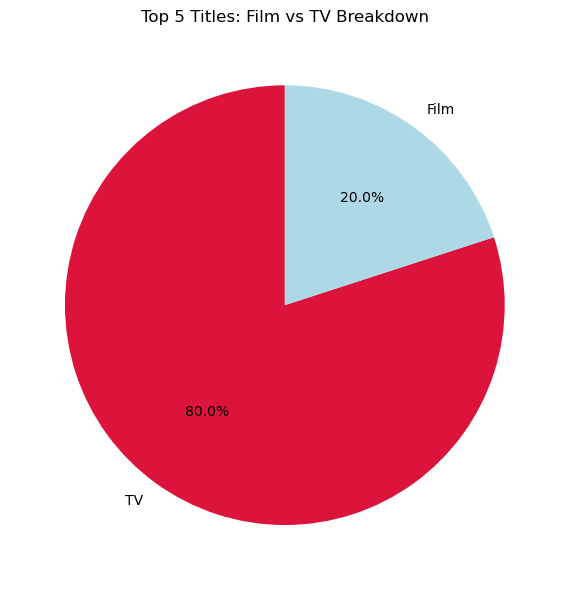

In [141]:
# Chart 5: Pie chart of Film vs TV among the Top 5 titles
top5_genres = global_weekly[global_weekly['show_title_clean'].isin(top5_final['show_title_clean'])]

# Get the most frequent category_simple per show
top5_main_category = (
    top5_genres.groupby('show_title_clean')['category_simple']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# Count category occurrences
category_counts = top5_main_category['category_simple'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['crimson', 'lightblue'])
plt.title('Top 5 Titles: Film vs TV Breakdown')
plt.tight_layout()
plt.savefig('chart_film_vs_tv.png', bbox_inches='tight')
plt.show()


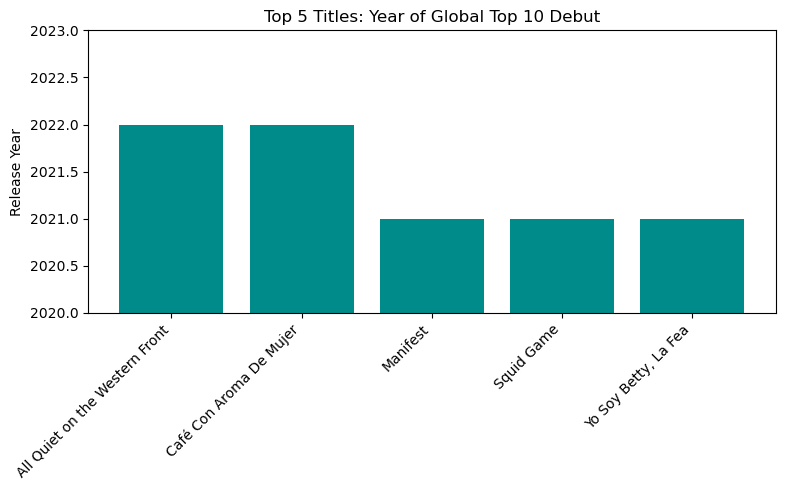

In [143]:
# Chart 6 bar chart of release years of Top 5 Titles

# get earliest week per title
release_weeks = (
    global_weekly[global_weekly['show_title_clean'].isin(top5_final['show_title_clean'])]
    .groupby('show_title_clean')['week']
    .min()
    .reset_index()
)

# extract the release year correctly
release_weeks['release_year'] = release_weeks['week'].dt.year

# merge with original title
release_weeks = release_weeks.merge(
    top5_final[['show_title_clean', 'show_title']],
    on='show_title_clean',
    how='left'
)

titles = release_weeks['show_title'].fillna(release_weeks['show_title_clean'].str.title())
years = release_weeks['release_year']

# plot bar chart with release years
plt.figure(figsize=(8, 5))
plt.bar(titles, years, color='darkcyan')
plt.ylabel('Release Year')
plt.title('Top 5 Titles: Year of Global Top 10 Debut')
plt.xticks(rotation=45, ha='right')
plt.ylim(years.min() - 1, years.max() + 1) 
plt.tight_layout()
plt.savefig('chart_release_years_fixed.png', bbox_inches='tight')
plt.show()


## Netflix Top 10 Longevity: A Data‐Driven Strategy

**Audience**
This analysis is for Netflix content strategy and acquisition teams—people who already understand high-level metrics like “hours viewed” but need a sharper lens on what signals long-term success. It’s not about technical jargon, it’s about telling a clear, story-driven narrative backed by data.

**Purpose**
The main goal is to show that “weeks in the Top 10” is a better indicator of staying power than just a strong debut. Instead of focusing on one-week spikes, this project highlights which shows had true staying power between 2021 and 2024. The findings help answer questions like: Which formats perform best over time? Are certain types of shows more likely to stick around globally?

**Medium & Design**
I used a PowerPoint deck because that’s how strategy teams usually absorb information—quick, visual insights, not code. Each slide is designed with a bold headline, a single chart, and a short explanation. Charts use Netflix-style colors (like red and gray) and are big enough to be readable in a meeting setting. Fonts are large and clean, and the goal is always to keep the focus on the data, not the formatting.

**Call to Action**
This analysis leads to three key suggestions:
- Invest in titles with proven longevity—especially mid-budget, international dramas.
- Start tracking “weeks in the Top 10” as a core success metric.
- Reallocate marketing efforts to keep strong titles visible beyond week one.

**Ethical Considerations**
All data comes directly from Netflix’s public Top 10 lists. This project doesn’t use any personal or private user data. Some titles were missing runtime or viewership numbers, but that didn’t impact the main metric used, cumulative weeks in the Top 10. I also cleaned and standardized show titles across datasets to avoid mismatches, and any decisions to drop or filter data were documented and justifiable.